In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive

# Drive mount karein
drive.mount('/content/drive')

# Updated Path ('Dataset' ka 'D' capital hai)
DATA_DIR = "/content/drive/MyDrive/Dataset/kaggle_3m"

# Folder ke contents read karein
folders = os.listdir(DATA_DIR)

# Print output
print(f"Total patient folders found: {len(folders)}")
print("Sample folders:", folders[:5])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total patient folders found: 112
Sample folders: ['README.md', 'data.csv', 'TCGA_HT_A61B_19991127', 'TCGA_HT_8114_19981030', 'TCGA_HT_A61A_20000127']


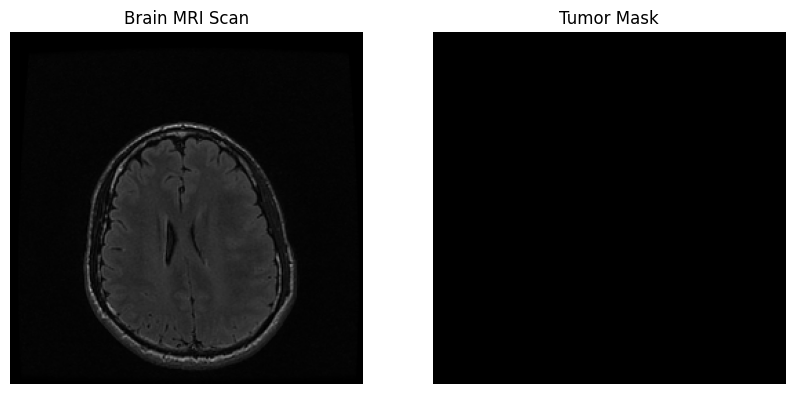

In [ ]:
import glob

# Kisi ek image aur uske mask ka path dhoondte hain
image_paths = glob.glob(DATA_DIR + "/*/*[0-9].tif") # Main image
mask_paths = [p.replace(".tif", "_mask.tif") for p in image_paths] # Mask image

# Sample 1 Image and Mask plot karte hain
sample_img = Image.open(image_paths[0])
sample_mask = Image.open(mask_paths[0])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(sample_img)
ax[0].set_title("Brain MRI Scan")
ax[0].axis("off")

ax[1].imshow(sample_mask, cmap="gray")
ax[1].set_title("Tumor Mask")
ax[1].axis("off")


plt.show()

Tumor Found AT index: 1


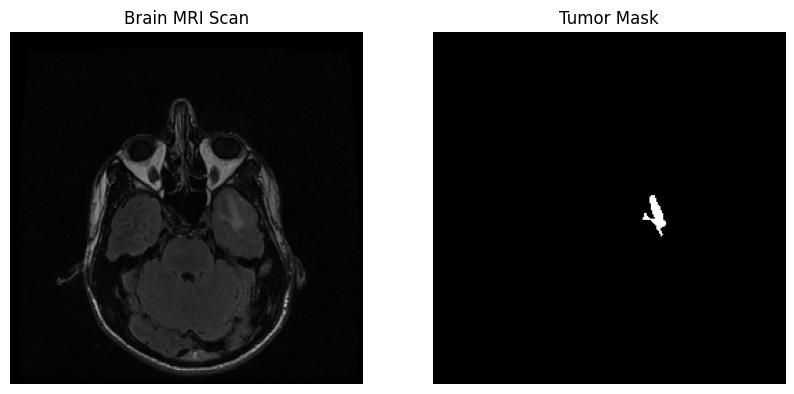

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

for i in range(len(image_paths)):
    m = Image.open(mask_paths[i])

    if np.max(np.array(m)) > 0:
        print(f"Tumor Found AT index: {i}")

        # 'ax' use karein taaki neeche ax[0] aur ax[1] se match ho
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        ax[0].imshow(Image.open(image_paths[i]))
        ax[0].set_title("Brain MRI Scan")
        ax[0].axis("off")

        ax[1].imshow(m, cmap="gray")
        ax[1].set_title("Tumor Mask")
        ax[1].axis("off")

        # In dono ko IF block ke andar hi indent karein
        plt.show()
        break

Tumor Found AT:1


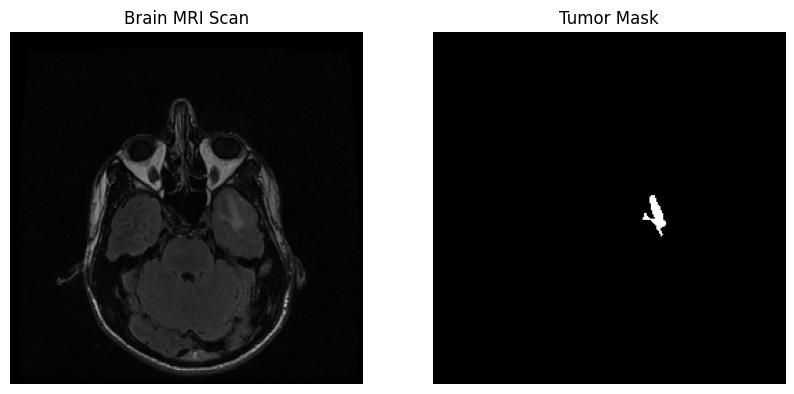

In [ ]:
import numpy as np

for i in range(len(image_paths)):

    m = Image.open(mask_paths[i])
    if np.max(np.array(m))>0:
        print(f"Tumor Found AT:{i}")

        fig , axis = plt.subplots(1,2,figsize=(10,5))
        axis[0].imshow(Image.open(image_paths[i]))
        axis[0].set_title("Brain MRI Scan")
        axis[0].axis("off")

        axis[1].imshow(m , cmap = "gray")
        axis[1].set_title("Tumor Mask")
        axis[1].axis("off")

        plt.show()
        break

In [ ]:
import os
import pandas as pd
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

def process_single_image(file_path):
    """Single image ka metadata read karne ke liye helper function"""
    filename = os.path.basename(file_path)
    try:
        file_size = os.path.getsize(file_path)

        with Image.open(file_path) as img:
            width, height = img.size
            img_format = img.format
            img_mode = img.mode

        return {
            "filename": filename,
            "file_path": file_path,
            "file_size_kb": round(file_size / 1024, 2),
            "width": width,
            "height": height,
            "aspect_ratio": round(width / height, 2) if height != 0 else 0,
            "format": img_format,
            "mode": img_mode,
        }
    except Exception as e:
        print(f"Skipping corrupt image {filename}: {e}")
        return None

def create_image_dataframe(image_dir, max_workers=32):
    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif")
    file_paths = []

    # 1. Fast file path collection
    for root, dirs, files in os.walk(image_dir):
        for filename in files:
            if filename.lower().endswith(valid_extensions):
                file_paths.append(os.path.join(root, filename))

    # 2. Parallel processing using Multi-threading
    data = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(process_single_image, file_paths)
        data = [res for res in results if res is not None]

    return pd.DataFrame(data)

In [ ]:
df = create_image_dataframe("/content/drive/MyDrive/Dataset/kaggle_3m")
print(df.head())

                            filename  \
0       TCGA_HT_A61B_19991127_54.tif   
1  TCGA_HT_A61B_19991127_55_mask.tif   
2  TCGA_HT_A61B_19991127_21_mask.tif   
3  TCGA_HT_A61B_19991127_35_mask.tif   
4  TCGA_HT_A61B_19991127_27_mask.tif   

                                           file_path  file_size_kb  width  \
0  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...        198.34    256   
1  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...         64.21    256   
2  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...         64.21    256   
3  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...         64.21    256   
4  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...         64.21    256   

   height  aspect_ratio format mode  
0     256           1.0   TIFF  RGB  
1     256           1.0   TIFF    L  
2     256           1.0   TIFF    L  
3     256           1.0   TIFF    L  
4     256           1.0   TIFF    L  


In [ ]:
import glob
import pandas as pd

all_files = glob.glob("./kaggle_3m/*/*.tif")
images = [f for f in all_files if "_mask" not in f]
mask  = [f for f in all_files if"_mask" in f]
images.sort()
mask.sort()
df=pd.DataFrame({"images_path":images , "mask_path" : mask})

In [ ]:
import numpy as np

def check_tumor(mask_path):

    mask = np.array(Image.open(mask_path))
    return 1 if np.max(mask) > 0 else 0
df["Has_tumor"] = df["mask_path"].apply(check_tumor)
print(df["Has_tumor"].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
df.columns

Index(['images_path', 'mask_path', 'Has_tumor'], dtype='object')

In [ ]:
df["Has_tumor"]

,Has_tumor


In [ ]:
print(len(images))
print(len(mask))

0
0


In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image

# 1. Tumhara dataset path
dataset_dir = "/content/drive/MyDrive/Dataset/kaggle_3m"

images = []
mask = []

# 2. Files ko correct tarike se find aur differentiate karna
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.tif', '.bmp')):
            full_path = os.path.join(root, file)

            # Mask images ke naam mein usually '_mask' hota hai
            if "_mask" in file.lower():
                mask.append(full_path)
            else:
                images.append(full_path)

# Paths ko sort karein taaki image aur uske mask ka order perfectly match ho
images.sort()
mask.sort()

# Verification check
print(f"Total Images Found: {len(images)}")
print(f"Total Masks Found: {len(mask)}")

# 3. Agar files mil gayi hain, tabhi DataFrame banayein
if len(images) > 0 and len(mask) > 0:
    df = pd.DataFrame({"images_path": images, "mask_path": mask})
    print("\nDataFrame successfully created!")
    print(df.head())
else:
    print("\n⚠️ ERROR: Abhi bhi 0 files milli! Path check karo ki Drive sahi se mount hai ya nahi.")

Total Images Found: 3929
Total Masks Found: 3929

DataFrame successfully created!
                                         images_path  \
0  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...   
1  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...   
2  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...   
3  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...   
4  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...   

                                           mask_path  
0  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...  
1  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...  
2  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...  
3  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...  
4  /content/drive/MyDrive/Dataset/kaggle_3m/TCGA_...  


In [ ]:
import numpy as np
from PIL import Image

# Tumor check karne ka function
def check_tumor(mask_path):
    try:
        mask = np.array(Image.open(mask_path))
        return 1 if np.max(mask) > 0 else 0
    except Exception as e:
        return 0

# Has_tumor column create karein
df["Has_tumor"] = df["mask_path"].apply(check_tumor)

# Final counts print karein
print("Tumor Counts:")
print(df["Has_tumor"].value_counts())

Tumor Counts:
Has_tumor
0    2556
1    1373
Name: count, dtype: int64


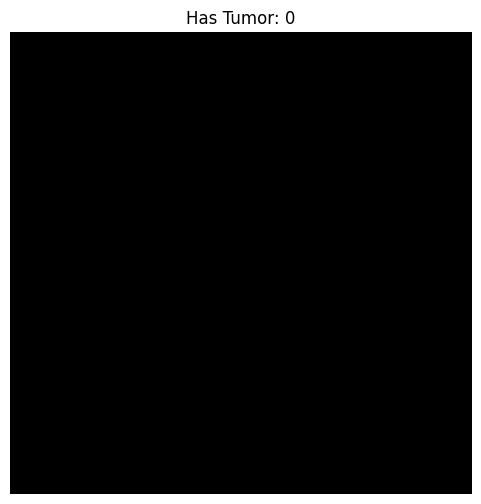

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Dataset se ek random row pick karein
random_row = df.sample(1).iloc[0]

# 2. Image aur Mask ke paths nikalen
# (Agar aapke pass image_path ka column hai to usko use karein)
img_path = random_row["mask_path"]  # Yahan mask_path ki jagah image wala column name bhi daal sakte hain

# 3. Image open karke display karein
img = Image.open(img_path)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")  # Mask ya grayscale ke liye cmap='gray' helpful rehta hai
plt.title(f"Has Tumor: {random_row['Has_tumor']}")
plt.axis("off")  # Axes hide karne ke liye
plt.show()

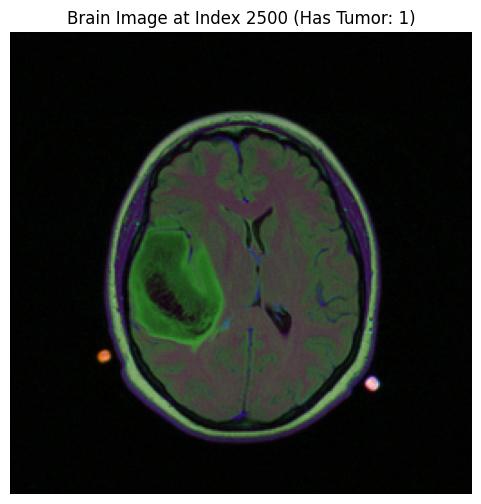

In [ ]:
index_num = 2500
row = df.iloc[index_num]

brain_img_path = row["images_path"]
img = Image.open(brain_img_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Brain Image at Index {index_num} (Has Tumor: {row['Has_tumor']})")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
image_array = np.array(img)
print("Imaeg Size :", image_array.shape)

Imaeg Size : (256, 256, 3)


In [ ]:
print("Min value : " , image_array.min())
print("Max value : " , image_array.max())

Min value :  0
Max value :  255


In [ ]:
image_normalized = image_array / 255.0
print("New  MIN  value : " , image_normalized.min())
print("New  MAX  value : " , image_normalized.max())

New  MIN  value :  0.0
New  MAX  value :  1.0


In [ ]:
print(df.isnull().sum())

images_path    0
mask_path      0
Has_tumor      0
dtype: int64


In [ ]:
print(df["Has_tumor"].value_counts())

Has_tumor
0    2556
1    1373
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
train_df , temp_df = train_test_split(
    df,
    test_size = 0.20,
    random_state=42,
    stratify=df["Has_tumor"]
)
val_df , test_df = train_test_split(
    temp_df,
    test_size = 0.50,
    random_state=42,
    stratify=temp_df["Has_tumor"]
)
print(f"Total images: {len(df)}")
print(f"Train Set: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val Set:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test Set:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Total images: 3929
Train Set: 3143 (80.0%)
Val Set:   393 (10.0%)
Test Set:  393 (10.0%)


PyTorch me jab aap loss function (BCEWithLogitsLoss) use karte hain, to aap usko bol sakte hain ke Tumor (1) wali mistakes par model ko zyada penalty de, kyunki uski images kam hain (1373 vs 2556).Calculate Weight Ratio:$$\text{weight} = \frac{\text{No Tumor Count (2556)}}{\text{Tumor Count (1373)}} \approx 1.86$$Code Example:Pythonimport torch
import torch.nn as nn

# Positive Class (Tumor = 1) ke liye weight set karein
pos_weight = torch.tensor([2556 / 1373]).to(device)  # ~1.86

# Loss function me pos_weight pass karein
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Training loop me standard tareeqe se use karein:
# loss = criterion(outputs, targets)
Iska faida: Model 1 (Tumor) ko ignore nahi karega aur us par zyada focus karega.

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
  def __init__(self , in_channels , out_channels):
    super(DoubleConv , self).__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels , out_channels , kernel_size = 3 , padding =1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace = True),
        nn.Conv2d(out_channels , out_channels , kernel_size = 3 , padding =1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace = True),
    )
  def forward(self ,x):
    return self.conv(x)


class UNet(nn.Module):
  def __init__(self , in_channels = 3 , out_channels = 1) :
      super(UNet , self).__init__()
      # -- Enoder --
      self.enc1 = DoubleConv(in_channels , 64)
      self.enc2 = DoubleConv(64 , 128)
      self.enc3 = DoubleConv(128 , 256)
      self.enc4 = DoubleConv(256 , 512)

      self.pool = nn.MaxPool2d(kernel_size=2 , stride = 2)

      self.bottleneck = DoubleConv(512 , 1024)

      # -- Decoder --
      self.upconv4 = nn.ConvTranspose2d(1024 , 512 , kernel_size=2 ,stride=2)
      self.dec4 = DoubleConv(1024 , 512)

      self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
      self.dec3 = DoubleConv(512, 256)   # 256 + 256 = 512

      self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
      self.dec2 = DoubleConv(256, 128)   # 128 + 128 = 256

      self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
      self.dec1 = DoubleConv(128, 64)

      self.final_conv = nn.Conv2d(64 , out_channels , kernel_size=1)

  def forward(self , x):
    enc1 = self.enc1(x)
    enc2 = self.enc2(self.pool(enc1))
    enc3 = self.enc3(self.pool(enc2))
    enc4 = self.enc4(self.pool(enc3))

    # Bottleneck
    bottleneck = self.bottleneck(self.pool(enc4))

    # Decoder forward pass with Skip Connections Concatenation
    dec4 = self.upconv4(bottleneck)
    dec4 = torch.cat((dec4, enc4), dim=1) # Skip connection 4
    dec4 = self.dec4(dec4)

    dec3 = self.upconv3(dec4)
    dec3 = torch.cat((dec3, enc3), dim=1) # Skip connection 3
    dec3 = self.dec3(dec3)

    dec2 = self.upconv2(dec3)
    dec2 = torch.cat((dec2, enc2), dim=1) # Skip connection 2
    dec2 = self.dec2(dec2)

    dec1 = self.upconv1(dec2)
    dec1 = torch.cat((dec1, enc1), dim=1) # Skip connection 1
    dec1 = self.dec1(dec1)

    return self.final_conv(dec1)



In [ ]:
# Model Instantiate karein
model = UNet(in_channels=3, out_channels=1)

# Dummy Image (Batch Size=2, Channels=3, Height=256, Width=256)
x = torch.randn((2, 3, 256, 256))

# Forward pass
output = model(x)

print("Input Shape: ", x.shape)
print("Output Mask Shape:", output.shape)
# Output Shape exact (2, 1, 256, 256) honi chahiye!

Input Shape:  torch.Size([2, 3, 256, 256])
Output Mask Shape: torch.Size([2, 1, 256, 256])


In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset , DataLoader
from PIL import Image


class SegmentationDataset(Dataset):
  def __init__(self , df , transform = None) :
    self.df = df
    self.transform = transform
  def __len__(self):
    return len(self.df)
  def __getitem__(self, idx):
    img_path = self.df.iloc[idx]["images_path"]
    mask_path = self.df.iloc[idx]["mask_path"]

    image = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    if self.transform:
      image = self.transform(image)
      mask = self.transform(mask)
    return image , mask

transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Model ke liye standard size
    transforms.ToTensor()           # Image ko PyTorch Tensor me convert karne ke liye
])

# 2. Ab Datasets Banayein
train_dataset = SegmentationDataset(train_df, transform=transform)
val_dataset   = SegmentationDataset(val_df, transform=transform)

# 3. Last me DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.7 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp
import torch
import torch.optim as optim

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3 , out_channels=1).to(device)

# 2. Short Loss & Optimizer Definition
criterion = smp.losses.DiceLoss(mode='binary')
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,          # Batch size 16 se barha kar 32 karne se speed fast hogi
    shuffle=True,
    num_workers=2,          # Data parallel load karega
    pin_memory=True         # GPU data transfer fast karta hai
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
df.columns

In [ ]:
print("Device:", device)
print("Batches per epoch:", len(train_loader))

num_epochs = 10

from tqdm import tqdm

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images, mask in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, mask)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

In [ ]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
  for images , masks in val_loader:
    images = images.to(device)
    masks = masks.to(device)

    outputs = model(images)

    preds = torch.sigmoid(outputs)
    preds = (preds > 0.5).float()
    break
img = images[0].cpu().permute(1 , 2, 0).numpy()
actual_mask = mask[0].cpu().squeeze().numpy()
pred_mask = preds[0].cpu().squeeze().numpy()

img = (img - img.min()) / (img.max() - img.min())

fig , ax =plt.subplots(1 , 3 , figsize = (15,5))
ax[0].imshow(img)
ax[0].set_title("1 Original Brain MRI")
ax[0].axis("off")

ax[1].imshow(actual_mask, cmap='gray')
ax[1].set_title("2. Actual Tumor Location")
ax[1].axis('off')

# Model Prediction Overlay
ax[2].imshow(img)
ax[2].imshow(pred_mask, cmap='jet', alpha=0.5)  # Color overlay
ax[2].set_title("3. U-Net Predicted Tumor")
ax[2].axis('off')

plt.tight_layout()
plt.show()
tumor_detected = pred_mask.sum() > 0
if tumor_detected:
    print("⚠️ RESULT: Brain Tumor Detected!")
else:
    print("✅ RESULT: No Tumor Found (Normal Brain).")